In [14]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split

In [15]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [16]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<Axes: xlabel='Churn'>

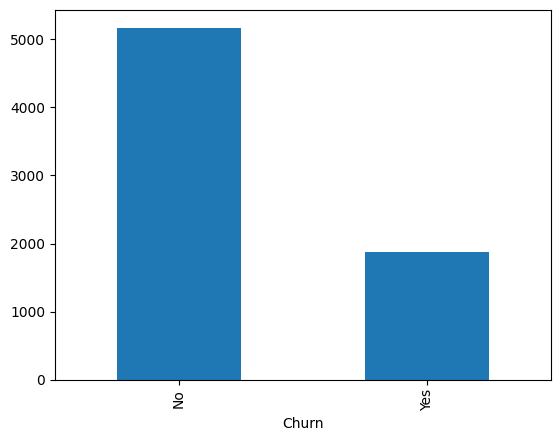

In [17]:
df['Churn'].value_counts().plot(kind='bar')

In [18]:
df_encoded = pd.get_dummies(df.drop(columns=['customerID']), drop_first=True)


In [19]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()
df['Churn']=label.fit_transform(df['Churn'])

In [20]:
from sklearn.model_selection import train_test_split
# Use stratified split to maintain class distribution in train/test sets
X = df_encoded.drop(columns=['Churn_Yes'])
y = df_encoded['Churn_Yes']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred)}")

Logistic Regression Accuracy: 0.7863733144073811


In [23]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(random_state=42, n_jobs=-1)
model2.fit(x_train_scaled,y_train)
y_pred_rf = model2.predict(x_test_scaled)


In [24]:
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf)}")

Random Forest Accuracy: 0.7998580553584103


In [25]:
from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier()
knn.fit(x_train_scaled, y_train)
y_pred_knn = knn.predict(x_test_scaled)

print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn)}")

KNN Accuracy: 0.7338537970191625


In [27]:
x_min=X.min()
x_max=X.max()
# convert bools to numeric and compute mins/maxes on numeric data, then scale
X_num = X.astype(float)
x_min = X_num.min()
x_max = X_num.max()
x_scaled = (X_num - x_min) / (x_max - x_min + 1e-8)
x_train_tf, x_test_tf, y_train_tf, y_test_tf = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model= keras.Sequential([
    layers.Input(shape=(x_train_tf.shape[1], )),
    layers.Dense(5, activation= 'relu'),
    layers.Dense(1, activation= 'sigmoid')
])
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
history= model.fit(
    x_train_tf.values,y_train.values,
    validation_data= (x_test_tf.values,y_test.values),
    epochs= 100,
    verbose=1,
    batch_size= 1000
)


Epoch 1/100
6/6 [==============================] - 1s 88ms/step - loss: 0.6970 - accuracy: 0.4397 - val_loss: 0.6923 - val_accuracy: 0.5479
Epoch 2/100
6/6 [==============================] - 0s 27ms/step - loss: 0.6892 - accuracy: 0.6246 - val_loss: 0.6826 - val_accuracy: 0.7168
Epoch 3/100
6/6 [==============================] - 0s 25ms/step - loss: 0.6778 - accuracy: 0.7235 - val_loss: 0.6686 - val_accuracy: 0.7324
Epoch 4/100
6/6 [==============================] - 0s 24ms/step - loss: 0.6641 - accuracy: 0.7334 - val_loss: 0.6554 - val_accuracy: 0.7346
Epoch 5/100
6/6 [==============================] - 0s 25ms/step - loss: 0.6516 - accuracy: 0.7341 - val_loss: 0.6436 - val_accuracy: 0.7353
Epoch 6/100
6/6 [==============================] - 0s 26ms/step - loss: 0.6405 - accuracy: 0.7346 - val_loss: 0.6331 - val_accuracy: 0.7353
Epoch 7/100
6/6 [==============================] - 0s 24ms/step - loss: 0.6305 - accuracy: 0.7345 - val_loss: 0.6236 - val_accuracy: 0.7353
Epoch 8/100
6/6 [===